<a href="https://colab.research.google.com/github/Harsh-Prajapati54/PyTorch-Learning-Journey/blob/master/Vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision-Transformer

In [17]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

from pathlib import Path

import requests

In [18]:
def download_data(source: str,
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.

    Returns:
        pathlib.Path to downloaded data.

    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it...
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)

        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...")
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)

    return image_path

def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

def set_seeds(seed: int=42):
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [20]:
device

'cuda'

### create a dataloader

In [21]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [22]:
import kagglehub

# 1. Download X-Ray dataset via Kagglehub
kaggle_path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

# The Kaggle dataset places images inside a "chest_xray" subfolder
image_path = Path(kaggle_path) / "chest_xray"
print("Path to dataset files:", image_path)

Using Colab cache for faster access to the 'labeled-chest-xray-images' dataset.
Path to dataset files: /kaggle/input/labeled-chest-xray-images/chest_xray


In [23]:
# 2. Setup directory paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [24]:
# 3. Define the transform for the Vision Transformer
image_size = 224
manual_transform = transforms.Compose([
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
])
print(f"Manually created transform: {manual_transform}")

Manually created transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [25]:
# 4. Create the Datasets using ImageFolder
train_data = datasets.ImageFolder(root=train_dir, transform=manual_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=manual_transform)

# Extract class names (will likely be ['NORMAL', 'PNEUMONIA'])
class_names = train_data.classes
print(f"Classes found: {class_names}")

Classes found: ['NORMAL', 'PNEUMONIA']


In [26]:
# 5. Turn Datasets into DataLoaders
batch_size = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=2) # num_workers speeds up data loading

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=batch_size,
                             shuffle=False,
                             num_workers=2)

print(f"Created train_dataloader with {len(train_dataloader)} batches.")
print(f"Created test_dataloader with {len(test_dataloader)} batches.")

Created train_dataloader with 164 batches.
Created test_dataloader with 20 batches.


In [27]:
from torch.utils.data import DataLoader

batch_size = 32

# 1. Create the Dataset object (this just loads the images and labels)
train_data = torchvision.datasets.ImageFolder(
    root=train_dir,
    transform=manual_transform,
    target_transform=None
)

# 2. Extract the class names from the dataset
class_names = train_data.classes
print(f"Classes: {class_names}")

# 3. Wrap the Dataset in a DataLoader (this turns it into iterable batches)
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
)

# 4. Repeat for the test data
test_data = torchvision.datasets.ImageFolder(
    root=test_dir,
    transform=manual_transform
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    shuffle=False # We usually don't shuffle test data
)

Classes: ['NORMAL', 'PNEUMONIA']


In [28]:
# get a batch of an image
image_batch , label_batch = next(iter(train_dataloader))

# get an single image from the batch
image, label = image_batch[0],label_batch[0]

#view a single batch
image.shape,label


(torch.Size([3, 224, 224]), tensor(1))

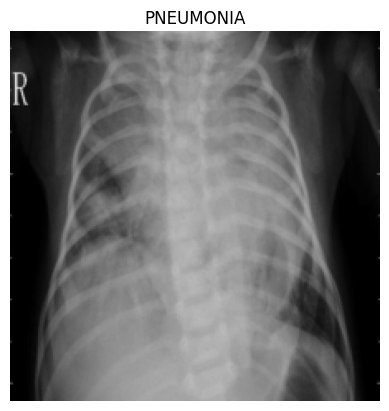

In [29]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

# Vit - Architecture

We'll start with the patch embedding.

This means we'll be turning our input images in a sequence of patches and then embedding those patches.

## Calculating patch embedding input and output shapes by hand
How about we start by calculating these input and output shape values by hand?

To do so, let's create some variables to mimic each of the terms (such as $H$, $W$ etc) above.

We'll use a patch size ($P$) of 16 since it's the best performing version of ViT-Base uses (see column "ViT-B/16" of Table 5 in the ViT paper for more).

In [30]:
height = 224
width = 224
color_channel = 3  # total 3 color reb blue green
patch_size = 16   # 16 pixel


# calculate the number of patches
number_of_patches = int((height * width) / patch_size**2)
number_of_patches

196

# Turning a single image into patches¶


Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


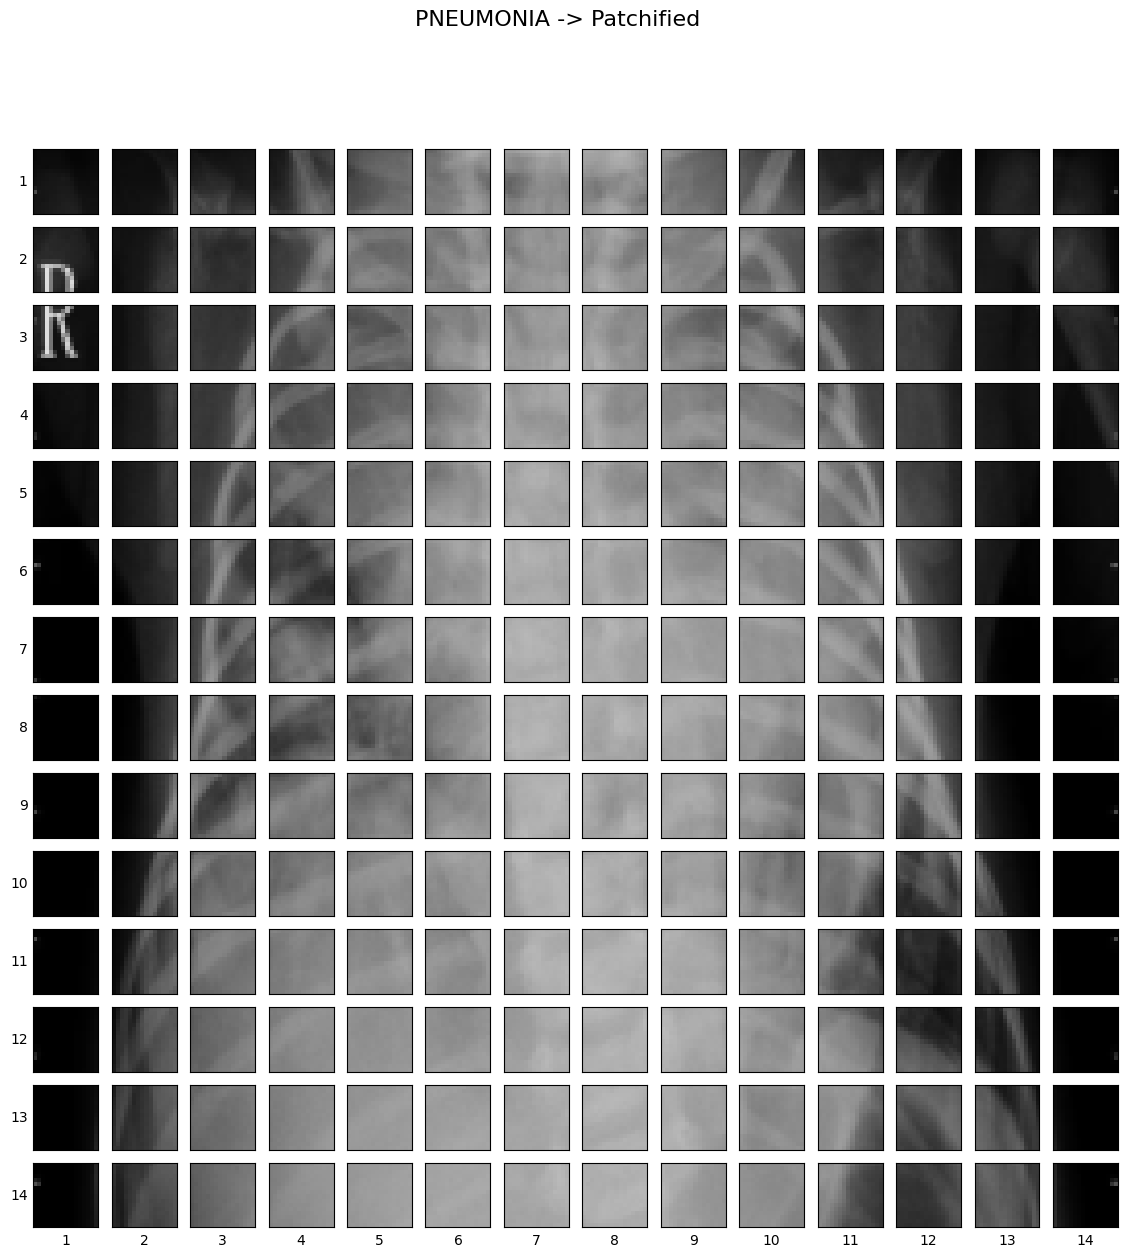

In [32]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Permute the image dimensions for matplotlib (CHW -> HWC)
image_permuted = image.permute(1, 2, 0)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()